In [2]:
import librosa

y, sr = librosa.load("/content/drive/MyDrive/audio.wav", sr=None)
print("Sampling Rate:", sr)
print("Duration (sec):", len(y)/sr)

Sampling Rate: 8000
Duration (sec): 7.424


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install numpy scipy matplotlib librosa

Sampling Rate: 8000
Duration (sec): 7.424


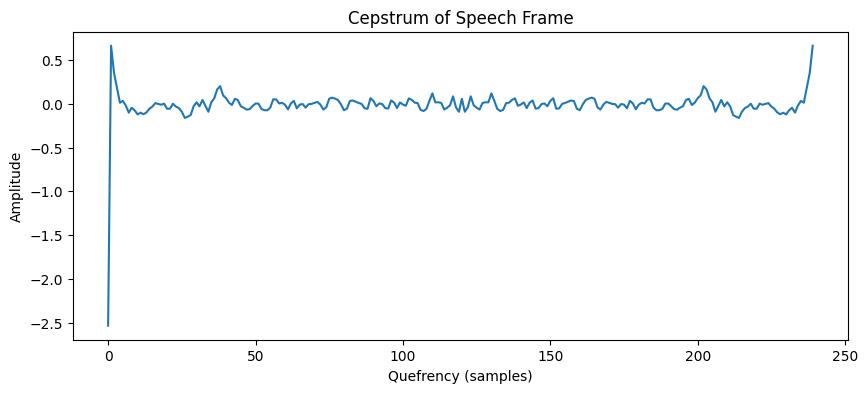


--- Pitch Detection ---
Pitch Period (sec): 0.01375
Fundamental Frequency F0 (Hz): 72.72727272727273


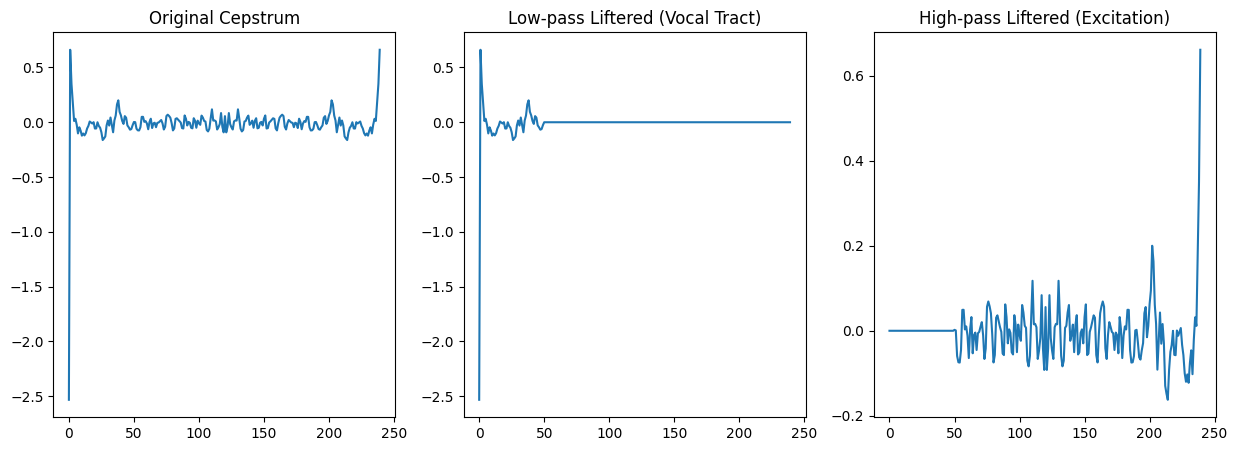

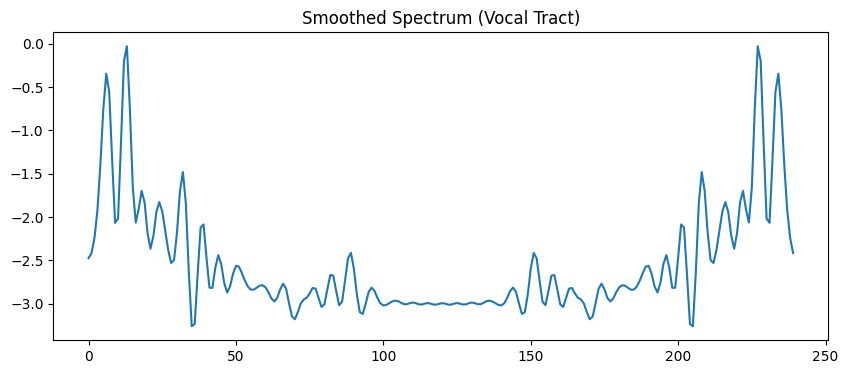

In [12]:
# ================================
# IMPORT LIBRARIES
# ================================
import numpy as np
import librosa
import matplotlib.pyplot as plt

# ================================
# LOAD AUDIO
# ================================
y, sr = librosa.load("/content/drive/MyDrive/audio.wav", sr=None)

print("Sampling Rate:", sr)
print("Duration (sec):", len(y)/sr)

# Convert to mono (if needed)
if len(y.shape) > 1:
    y = y.mean(axis=1)

# ================================
# FRAME SELECTION (IMPORTANT FIX)
# ================================
frame_length = int(0.03 * sr)  # 30 ms

# Choose high-energy region instead of random
start = np.argmax(np.abs(y))
frame = y[start:start + frame_length]

# Apply Hamming window
frame = frame * np.hamming(len(frame))

# ================================
# A. REAL CEPSTRUM
# ================================
spectrum = np.fft.fft(frame)
log_mag = np.log(np.abs(spectrum) + 1e-10)
cepstrum = np.fft.ifft(log_mag).real

# ================================
# B. PLOT CEPSTRUM
# ================================
plt.figure(figsize=(10,4))
plt.plot(cepstrum)
plt.title("Cepstrum of Speech Frame")
plt.xlabel("Quefrency (samples)")
plt.ylabel("Amplitude")
plt.show()

# ================================
# C. PITCH DETECTION
# ================================
# Quefrency axis (in seconds)
quefrency = np.arange(len(cepstrum)) / sr

# Pitch range: 5 ms to 20 ms
min_q = int(0.005 * sr)
max_q = int(0.02 * sr)

# Find peak
pitch_index = np.argmax(cepstrum[min_q:max_q]) + min_q
pitch_period = pitch_index / sr
F0 = 1 / pitch_period

print("\n--- Pitch Detection ---")
print("Pitch Period (sec):", pitch_period)
print("Fundamental Frequency F0 (Hz):", F0)

# ================================
# D. CEPSTRAL LIFTERING
# ================================

# Low-pass liftering (Vocal Tract)
lifter_low = np.copy(cepstrum)
lifter_low[50:] = 0

# High-pass liftering (Excitation)
lifter_high = np.copy(cepstrum)
lifter_high[:50] = 0

# ================================
# PLOT LIFTERING RESULTS
# ================================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(cepstrum)
plt.title("Original Cepstrum")

plt.subplot(1,3,2)
plt.plot(lifter_low)
plt.title("Low-pass Liftered (Vocal Tract)")

plt.subplot(1,3,3)
plt.plot(lifter_high)
plt.title("High-pass Liftered (Excitation)")

plt.show()

# ================================
# OPTIONAL: RECONSTRUCT SPECTRUM
# ================================

# Vocal tract spectrum
smooth_spectrum = np.exp(np.fft.fft(lifter_low).real)

plt.figure(figsize=(10,4))
plt.plot(np.log(smooth_spectrum + 1e-10))
plt.title("Smoothed Spectrum (Vocal Tract)")
plt.show()

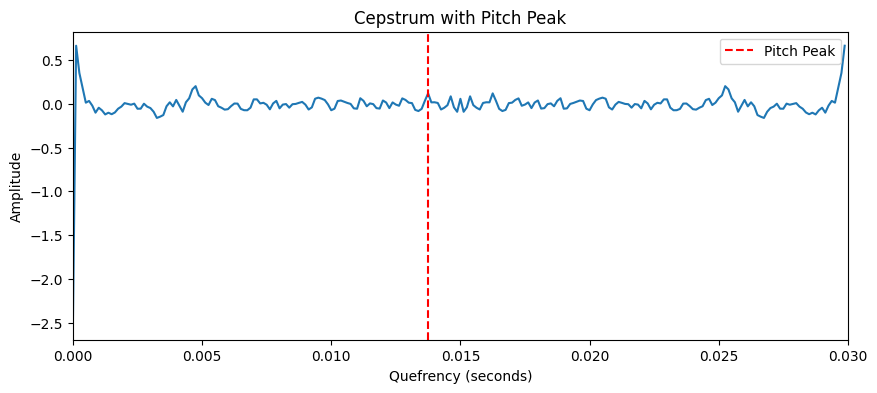

In [13]:
plt.figure(figsize=(10,4))
plt.plot(quefrency, cepstrum)
plt.axvline(pitch_period, color='r', linestyle='--', label='Pitch Peak')
plt.xlim(0, 0.03)  # zoom into important region
plt.xlabel("Quefrency (seconds)")
plt.ylabel("Amplitude")
plt.title("Cepstrum with Pitch Peak")
plt.legend()
plt.show()